In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
from torchvision.ops import box_area
import imblearn
from collections import Counter


In [2]:
#lab_df = pd.read_csv('wf_labelled_data.csv')
lab_df = pd.read_csv('../Downloads/data-2022-08-01.csv')


In [3]:
labeler_root = 'GitHub/audio_labeller/www'
labeler_list = [l for l in os.listdir(labeler_root) if l not in ['tmp', 'JS']]
labeler_list


['davidfunosas',
 'hhussey3',
 'irishwildlifesounds',
 'markshorten',
 'mcauchoixxx']

In [4]:
lab_prefix = [v.split('@')[0] for v in lab_df.labeler]
lab_df['lab_folder'] = [l if l in labeler_list else 'tmp' for l in lab_prefix]


In [5]:
lab_df


,date_time,file_name,start_time,end_time,start_freq,end_freq,class_label,call_type,confidence,notes,labeler,id,lab_folder
0,22/05/2022 15:14,RICHFIELDM1_20220413_133400_start_0_14.wav,11.518955,12.280277,4.119626,6.176058,Eurasian Magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,1,tmp
1,22/05/2022 15:16,RICHFIELDM1_20220413_133400_start_0_14.wav,12.542371,14.189820,5.334790,9.307442,Eurasian Magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,2,tmp
2,22/05/2022 15:17,RICHFIELDM1_20220413_133400_start_0_14.wav,8.099250,9.322356,8.512912,10.195447,Eurasian Magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,3,tmp
3,22/05/2022 15:18,RICHFIELDM1_20220413_133400_start_0_14.wav,7.275526,8.698323,4.960893,7.484696,Eurasian Magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,5,tmp
4,22/05/2022 15:22,RICHFIELDM1_20220413_133400_start_0_14.wav,2.745040,3.755975,8.185752,10.943240,Eurasian Magpie,NaN,1.00,NaN,anthony.gibbons.2022@mumail.ie,6,tmp
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,15/08/2022 19:52,TEEVURCHER_20220530_190500_start_2_20.wav,1.822838,4.161781,0.631594,3.536837,Blackbird,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2155,15/08/2022 19:53,TEEVURCHER_20220530_192000_start_3_16.wav,3.770404,6.547316,0.725312,8.035277,hooded crow,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2156,15/08/2022 19:53,TEEVURCHER_20220530_192000_start_3_30.wav,9.883339,10.405175,-0.011719,10.940520,Anthropogenic Noise,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten
2157,15/08/2022 19:53,TEEVURCHER_20220530_192000_start_3_30.wav,5.382504,5.690014,-0.011719,10.050203,Anthropogenic Noise,NaN,0.95,NaN,markshorten@icloud.com,1,markshorten


In [6]:
# lab_df[~lab_df.notes.isna()]


In [7]:
audio_paths = [os.path.join('wf_data_clips', r.file_name)
               for i, r in lab_df.iterrows()]
audio_paths_exists = [os.path.exists(p) for p in audio_paths]
# do they all exist
np.mean(audio_paths_exists)


0.9953682260305697

In [8]:
pop_classes = ["Blackbird",
               "Chaffinch",
               "Dunnock",
               "Goldfinch",
               "Hooded Crow",
               "House Sparrow",
               "Linnet",
               "Meadow Pipit",
               "Pied Wagtail",
               "Robin",
               "Rook",
               "Sedge Warbler",
               "Starling",
               "Stonechat",
               "Wren",
               "Yellowhammer"]


In [9]:
df = lab_df[audio_paths_exists].copy()


In [10]:
df.class_label = df.class_label.str.capitalize()


In [11]:
df_popclasses = df[df.class_label.isin(pop_classes)]


In [12]:
df_f1 = df_popclasses[df_popclasses.file_name ==
                      df_popclasses.file_name.iloc[5]]
df_f1


,date_time,file_name,start_time,end_time,start_freq,end_freq,class_label,call_type,confidence,notes,labeler,id,lab_folder
13,31/05/2022 12:59,RICHFIELDM1_20220413_134900_start_1_24.wav,6.995676,12.287472,1.019056,9.104018,Wren,song,1.00,NaN,djkelly@tcd.ie,1,tmp
14,31/05/2022 13:00,RICHFIELDM1_20220413_134900_start_1_24.wav,0.344897,0.931730,0.078944,11.988281,Rook,call,1.00,NaN,djkelly@tcd.ie,1,tmp
15,31/05/2022 13:02,RICHFIELDM1_20220413_134900_start_1_24.wav,7.932550,9.796004,0.125950,11.830342,Rook,call,1.00,NaN,djkelly@tcd.ie,1,tmp
16,31/05/2022 13:03,RICHFIELDM1_20220413_134900_start_1_24.wav,14.017087,14.984847,0.078944,11.689326,Rook,call,1.00,NaN,djkelly@tcd.ie,1,tmp
122,08/06/2022 22:06,RICHFIELDM1_20220413_134900_start_1_24.wav,7.203190,12.164438,3.564768,8.995941,Wren,NaN,1.00,NaN,hhussey3@gmail.com,1,hhussey3
123,08/06/2022 22:06,RICHFIELDM1_20220413_134900_start_1_24.wav,7.366236,12.176084,0.967251,3.234175,Blackbird,NaN,1.00,NaN,hhussey3@gmail.com,1,hhussey3
191,30/05/2022 14:25,RICHFIELDM1_20220413_134900_start_1_24.wav,7.291703,11.285242,2.787097,10.143921,Wren,call,1.00,NaN,markshorten@icloud.com,1,markshorten
1426,20/06/2022 16:03,RICHFIELDM1_20220413_134900_start_1_24.wav,7.413937,12.110460,3.630554,8.597582,Wren,call,0.95,NaN,markshorten@icloud.com,1,markshorten
1427,20/06/2022 16:03,RICHFIELDM1_20220413_134900_start_1_24.wav,7.106426,9.883339,0.912747,2.365368,Rook,call,0.45,NaN,markshorten@icloud.com,1,markshorten
1428,20/06/2022 16:03,RICHFIELDM1_20220413_134900_start_1_24.wav,0.527567,1.040084,0.725312,2.459085,Rook,call,0.45,NaN,markshorten@icloud.com,1,markshorten


In [13]:
def bbox_fn(x):
    bboxes = torch.tensor(
        x[['start_time', 'start_freq', 'end_time', 'end_freq']].values)
    return box_area(bboxes).sum().item()


In [14]:
df_bboxes = df_popclasses.groupby(
    ["file_name", "class_label"]).apply(bbox_fn).reset_index()
df_bboxes.columns = df_bboxes.columns[:-1].to_list() + ["bbox_sum"]

df_bboxes = df_bboxes.sort_values(
    by=['file_name', 'bbox_sum'])  # , drop_duplicates()
df_singlelabs = df_bboxes.drop_duplicates("file_name", keep="last")


In [15]:
df_singlelabs


,file_name,class_label,bbox_sum
0,CARNSOREMET_20220427_154300_start_0_28.wav,Stonechat,17.311219
2,CARNSOREMET_20220427_154300_start_2_34.wav,Stonechat,11.350224
3,CARNSOREMET_20220427_160300_start_0_28.wav,Stonechat,29.043712
4,CARNSOREMET_20220427_160300_start_1_24.wav,Blackbird,1.937444
5,CARNSOREMET_20220427_160300_start_1_38.wav,Blackbird,1.883127
...,...,...,...
562,TEEVURCHER_20220530_183500_start_3_30.wav,Robin,19.667733
563,TEEVURCHER_20220530_183500_start_3_44.wav,Blackbird,19.715765
564,TEEVURCHER_20220530_183500_start_3_58.wav,Robin,12.470815
565,TEEVURCHER_20220530_190500_start_1_52.wav,Blackbird,10.344314


In [16]:
pop_classes = df_singlelabs.class_label.unique()

In [17]:
#filenames = tf.io.gfile.glob(str(data_dir) + '/*/*')
wav_paths = [os.path.join('wf_data_clips', r.file_name)
             for i, r in df_singlelabs.iterrows()]
filenames = tf.convert_to_tensor(np.unique(np.array(wav_paths)))
#filenames = tf.random.shuffle(filenames)
num_samples = len(filenames)
print('Number of total examples:', num_samples)
# print('Number of examples per label:',
#      len(tf.io.gfile.listdir(str(data_dir/commands[0]))))
print('Example file tensor:', filenames[0])


Number of total examples: 426
Example file tensor: tf.Tensor(b'wf_data_clips\\CARNSOREMET_20220427_154300_start_0_28.wav', shape=(), dtype=string)


In [18]:
filenames = [f.numpy().decode().replace('\\', '/') for f in filenames]
#filenames = [f.replace('/', os.path.sep) for f in filenames]
filenames = [f for f in filenames if os.path.exists(f)]
filenames[:5]


['wf_data_clips/CARNSOREMET_20220427_154300_start_0_28.wav',
 'wf_data_clips/CARNSOREMET_20220427_154300_start_2_34.wav',
 'wf_data_clips/CARNSOREMET_20220427_160300_start_0_28.wav',
 'wf_data_clips/CARNSOREMET_20220427_160300_start_1_24.wav',
 'wf_data_clips/CARNSOREMET_20220427_160300_start_1_38.wav']

In [19]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
batch_size = 32
EPOCHS = 50


In [20]:
from tf_helpers import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, top_k_accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from math import prod


In [21]:
Counter(df_singlelabs.class_label.values)

Counter({'Stonechat': 10,
         'Blackbird': 142,
         'Goldfinch': 7,
         'Wren': 82,
         'Linnet': 39,
         'Dunnock': 20,
         'Chaffinch': 37,
         'Robin': 49,
         'Yellowhammer': 13,
         'Rook': 16,
         'Starling': 11})

In [22]:
filename_df = pd.DataFrame({'name': filenames,
                            'label': df_singlelabs.class_label.values})

In [26]:
filename_df = filename_df[filename_df.label != "Goldfinch"]

In [27]:
Counter(filename_df.label)

Counter({'Stonechat': 10,
         'Blackbird': 142,
         'Wren': 82,
         'Linnet': 39,
         'Dunnock': 20,
         'Chaffinch': 37,
         'Robin': 49,
         'Yellowhammer': 13,
         'Rook': 16,
         'Starling': 11})

In [29]:
#filenames   = tf.random.shuffle(filenames)
#all_labs    = [get_label(y).numpy().decode() for y in filenames]


# , stratify=filename_df[['label']])
train, rest_df = train_test_split(filename_df, test_size=0.2, stratify=filename_df[['label']])
# , stratify = rest_df[['label']])
val, test = train_test_split(rest_df, test_size=0.5, stratify = rest_df[['label']])

train_files = tf.random.shuffle(train['name'])
val_files = tf.random.shuffle(val['name'])
test_files = tf.random.shuffle(test['name'])


In [30]:
choices = ['Mod']
categories = pop_classes


In [31]:
def get_labname(x):
    return x, filename_df[filename_df.name == x].label


In [32]:
t_ds = tf.data.Dataset.from_tensor_slices(train)


In [33]:
for x, y in t_ds.take(1):
    print(x)
    print(y)


tf.Tensor(b'wf_data_clips/TEEVURCHER_20220530_183500_start_3_58.wav', shape=(), dtype=string)
tf.Tensor(b'Robin', shape=(), dtype=string)


In [34]:
def get_waveform_and_label(x_tuple):
    file_path, label = x_tuple[0], x_tuple[1]
    audio_binary = tf.io.read_file(file_path)
    waveform, sr = decode_audio(audio_binary)
    return waveform[:15*sr], label


In [35]:
wave_ds = t_ds.map(get_waveform_and_label, num_parallel_calls=AUTOTUNE)


In [36]:
for x, y in wave_ds.take(1):
    aud = x
    spec = gen_complex_spec(aud, 44100)
    # print(spec.shape)
    # print(x)
    # print(y)


In [37]:
complex_spec = gen_complex_spec(aud, 44100)


In [38]:
spec = multi_spec_stack(complex_spec, ['Mod'])
#spec


In [39]:
def get_spectrogram_and_label_id(x_tuple, choices=['Mod'], categories=pop_classes, req_width=400, single_to_rgb=False, resize=1, spec_norm=False):
    audio, label = x_tuple[0], x_tuple[1]
    #spectrogram = get_complex_spectrogram(audio)
    # print(dir(audio))
    aud, sr = audio, 44100
    #aud, sr      = audio
    complex_spec = gen_complex_spec(aud, sr)
    multi_spec = multi_spec_stack(complex_spec, choices)
    multi_spec = multi_spec_post(multi_spec, req_width, spec_norm, resize)
    if single_to_rgb:
        multi_spec = tf.concat([multi_spec, multi_spec, multi_spec], axis=-1)
        multi_spec = tf.stack(multi_spec)
    #multi_spec = complex_spec
    spec_shape = tf.shape(multi_spec)
    if resize > 1:
        multi_spec = tf.image.resize(
            multi_spec, [spec_shape[0]//resize, spec_shape[1]//resize])
    label_id = tf.argmax(label == categories)
    return multi_spec, label_id


In [40]:
output_ds = wave_ds.map(lambda x, y: get_spectrogram_and_label_id((x, y)),
                        num_parallel_calls=AUTOTUNE)


In [41]:
# def preprocess_dataset(files, choices, categories, req_width = 250, single_to_rgb = False, resize = 1, spec_norm = False):
#AUTOTUNE  = tf.data.experimental.AUTOTUNE
#files_ds  = tf.data.Dataset.from_tensor_slices(train.name)
#output_ds = t_ds.map(get_labname, num_parallel_calls=AUTOTUNE)
#wave_ds = t_ds.map(lambda x,y: get_waveform_and_label(file_path=x, label=y), num_parallel_calls=AUTOTUNE)
#output_ds = wave_ds.map(get_spectrogram_and_label_id, num_parallel_calls=AUTOTUNE)
def preprocess_dataset(df):
    t_ds = tf.data.Dataset.from_tensor_slices(df)
    wave_ds = t_ds.map(get_waveform_and_label, num_parallel_calls=AUTOTUNE)
    output_ds = wave_ds.map(lambda x, y: get_spectrogram_and_label_id(
        (x, y)),  num_parallel_calls=AUTOTUNE)
    return output_ds
#output_ds = output_ds.map(lambda x,y : spec_unstack(spec=x, label=y), num_parallel_calls=AUTOTUNE)
# return output_ds


In [42]:

train_ds = preprocess_dataset(train)
val_ds = preprocess_dataset(val)
test_ds = preprocess_dataset(test)


In [43]:
train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)


In [44]:
def best_model_cp():
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        "best_model",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True)
    return checkpoint


In [45]:
for spec, lab in train_ds.take(1):
    inp_shape = spec.shape[1:]


In [46]:
from collections import Counter


In [47]:
for x, y in train_ds.unbatch().take(1):
    spec = spec[0, :, :, :]
    print(x.shape)


(512, 400, 1)


In [48]:
spec.shape


TensorShape([512, 400, 1])

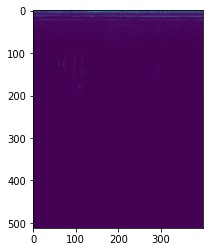

In [49]:
plt.imshow(spec)


In [50]:
y_true = [y.numpy() for _, y in train_ds.unbatch()]
#[y for y in y_true]
Counter(y_true)


Counter({7: 39, 8: 10, 1: 113, 6: 30, 3: 66, 5: 16, 9: 13, 10: 9, 4: 31, 0: 8})

In [51]:
model = main_cnn(inp_shape, num_classes=len(categories))
#model_name   = 'smallcnn'
#filename_run = filename_idx+'_'+model_name

history = model.fit(train_ds,
                    validation_data=val_ds,
                    callbacks=[best_model_cp()],
                    epochs=10,  # 50,
                    verbose=1)


Epoch 1/10
11/11 [==============================] - 11s 963ms/step - loss: 2.4405 - accuracy: 0.1821 - val_loss: 2.1995 - val_accuracy: 0.2143
Epoch 2/10
11/11 [==============================] - 11s 1s/step - loss: 2.2072 - accuracy: 0.2627 - val_loss: 2.1169 - val_accuracy: 0.5000
Epoch 3/10
11/11 [==============================] - 12s 1s/step - loss: 1.9902 - accuracy: 0.4119 - val_loss: 1.9709 - val_accuracy: 0.4762
Epoch 4/10
11/11 [==============================] - 13s 1s/step - loss: 1.8270 - accuracy: 0.5015 - val_loss: 1.8718 - val_accuracy: 0.5476
Epoch 5/10
11/11 [==============================] - 13s 1s/step - loss: 1.7068 - accuracy: 0.5194 - val_loss: 1.6806 - val_accuracy: 0.5238
Epoch 6/10
11/11 [==============================] - 14s 1s/step - loss: 1.6228 - accuracy: 0.5343 - val_loss: 1.6758 - val_accuracy: 0.5238
Epoch 7/10
11/11 [==============================] - 15s 1s/step - loss: 1.4898 - accuracy: 0.5701 - val_loss: 1.6138 - val_accuracy: 0.5476
Epoch 8/10
11/11 

In [76]:
history = model.fit(train_ds,
                    validation_data=val_ds,
                    callbacks=[best_model_cp()],
                    epochs=10,  # 50,
                    verbose=1)

Epoch 1/10
11/11 [==============================] - 11s 947ms/step - loss: 1.2222 - accuracy: 0.6567 - val_loss: 1.4664 - val_accuracy: 0.5476
Epoch 2/10
11/11 [==============================] - 10s 933ms/step - loss: 1.2223 - accuracy: 0.6716 - val_loss: 1.3892 - val_accuracy: 0.5952
Epoch 3/10
11/11 [==============================] - 11s 958ms/step - loss: 1.1854 - accuracy: 0.6746 - val_loss: 1.3992 - val_accuracy: 0.5714
Epoch 4/10
11/11 [==============================] - 11s 1s/step - loss: 1.1781 - accuracy: 0.6806 - val_loss: 1.3906 - val_accuracy: 0.6429
Epoch 5/10
11/11 [==============================] - 12s 1s/step - loss: 1.1366 - accuracy: 0.6985 - val_loss: 1.4406 - val_accuracy: 0.5476
Epoch 6/10
11/11 [==============================] - 12s 1s/step - loss: 1.0818 - accuracy: 0.7015 - val_loss: 1.3781 - val_accuracy: 0.6190
Epoch 7/10
11/11 [==============================] - 13s 1s/step - loss: 1.1573 - accuracy: 0.7164 - val_loss: 1.4075 - val_accuracy: 0.5714
Epoch 8/10


In [77]:
history = model.fit(train_ds,
                    validation_data=val_ds,
                    callbacks=[best_model_cp()],
                    epochs=5,  # 50,
                    verbose=1)

Epoch 1/5
11/11 [==============================] - 17s 2s/step - loss: 0.9253 - accuracy: 0.7373 - val_loss: 1.4464 - val_accuracy: 0.5952
Epoch 2/5
11/11 [==============================] - 15s 1s/step - loss: 0.9002 - accuracy: 0.7493 - val_loss: 1.3396 - val_accuracy: 0.6667
Epoch 3/5
11/11 [==============================] - 15s 1s/step - loss: 0.8815 - accuracy: 0.7821 - val_loss: 1.4490 - val_accuracy: 0.5714
Epoch 4/5
11/11 [==============================] - 16s 1s/step - loss: 0.8598 - accuracy: 0.7851 - val_loss: 1.3745 - val_accuracy: 0.6429
Epoch 5/5
11/11 [==============================] - 15s 1s/step - loss: 0.8351 - accuracy: 0.7731 - val_loss: 1.3940 - val_accuracy: 0.5952


In [78]:
model.load_weights("best_model")

In [79]:
pred_lists = model.predict(test_ds)
np.argmax(pred_lists, axis=-1), np.array([y for _, y in test_ds])[0]


<ipython-input-79-ef68c1cbdba9>:2: VisibleDeprecationWarning:

Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray



(array([3, 1, 3, 3, 1, 1, 3, 1, 5, 1, 1, 1, 7, 6, 7, 3, 3, 1, 1, 1, 1, 1,
        3, 6, 3, 6, 4, 3, 6, 1, 3, 3, 1, 7, 1, 3, 1, 3, 3, 1, 1, 3],
       dtype=int64),
 <tf.Tensor: shape=(32,), dtype=int64, numpy=
 array([ 3,  4,  5,  9,  1, 10,  9,  0,  4,  1,  1,  1,  7,  6,  7,  3,  7,
         1,  1,  4,  1,  1,  4,  6,  5,  6,  1,  3,  6,  1,  3,  3],
       dtype=int64)>)

In [80]:
len(categories)

11

In [81]:
y_true

array([ 3,  4,  5,  9,  1, 10,  9,  0,  4,  1,  1,  1,  7,  6,  7,  3,  7,
        1,  1,  4,  1,  1,  4,  6,  5,  6,  1,  3,  6,  1,  3,  3,  1,  7,
        1,  3,  8,  7,  3,  1,  1,  3], dtype=int64)

In [82]:
pred_lists = model.predict(test_ds)
y_pred = np.argmax(pred_lists, axis=-1)
y_true = np.array([y for _, y in test_ds.unbatch()])
pred_df    = pd.DataFrame(pred_lists, columns = categories)

#softmax_prediction_df = pred_df.apply(lambda x: np.exp(x - np.max(x))/np.exp(x - np.max(x)).sum(), axis=1)
# softmax_prediction_df.to_csv('results/'+filename_run+'_softmax_prediction_df.csv')

cm = confusion_matrix(y_true, y_pred, labels=[
                      i for i in range(len(categories))])
fig = plotly_cm(cm, list(pop_classes))


In [83]:
fig

In [ ]:
#leave one out or 10-fold cross validation
#investigate mislabeled classes (look plus listen)

In [85]:
pred_lists = model.predict(train_ds)
y_pred = np.argmax(pred_lists, axis=-1)
y_true = np.array([y for _, y in train_ds.unbatch()])
pred_df    = pd.DataFrame(pred_lists, columns = categories)

#softmax_prediction_df = pred_df.apply(lambda x: np.exp(x - np.max(x))/np.exp(x - np.max(x)).sum(), axis=1)
# softmax_prediction_df.to_csv('results/'+filename_run+'_softmax_prediction_df.csv')

cm = confusion_matrix(y_true, y_pred, labels=[
                      i for i in range(len(categories))])
fig = plotly_cm(cm, list(pop_classes))
fig

In [73]:
Counter(test.label)

Counter({'Wren': 8,
         'Linnet': 4,
         'Dunnock': 2,
         'Rook': 2,
         'Blackbird': 14,
         'Starling': 1,
         'Stonechat': 1,
         'Robin': 5,
         'Chaffinch': 4,
         'Yellowhammer': 1})

In [51]:
# summarize class distribution
counter = Counter(y_true)
print(counter)


Counter({0: 125, 14: 76, 9: 45, 1: 36, 6: 34, 2: 16, 10: 14, 13: 10, 12: 10, 15: 10, 3: 7})


c:\Users\Anthony\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



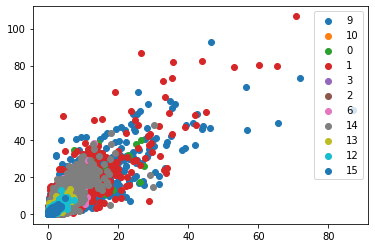

In [52]:
# scatter plot of examples by class label
for label, _ in counter.items():
    row_ix = np.where(y_true == label)[0]
    plt.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
plt.legend()
plt.show()


In [54]:
X_rs = X.reshape((X.shape[0], -1))


In [55]:
# transform the dataset
#oversample = imblearn.over_sampling.SMOTE(k_neighbors=4)
#X_rs, y_true = oversample.fit_resample(X_rs, y_true)


In [58]:
#X_bal = X_rs.reshape((X_rs.shape[0], X.shape[1], X.shape[2], X.shape[3]))
#X_bal.shape


(1375, 512, 400, 1)

In [59]:
#Counter(y_true)


Counter({9: 125,
         10: 125,
         0: 125,
         1: 125,
         3: 125,
         2: 125,
         6: 125,
         14: 125,
         13: 125,
         12: 125,
         15: 125})

In [60]:
model_bal = main_cnn(inp_shape, num_classes=len(categories))
#model_name   = 'smallcnn'
#filename_run = filename_idx+'_'+model_name

#history = model_bal.fit(X_bal, y_true,
#                        validation_data=val_ds,
#                        callbacks=[best_model_cp()],
#                        epochs=15,  # 50,
#                        verbose=1)


Epoch 1/15
43/43 [==============================] - 81s 2s/step - loss: 2.6727 - accuracy: 0.1222 - val_loss: 2.4103 - val_accuracy: 0.2857
Epoch 2/15
43/43 [==============================] - 81s 2s/step - loss: 2.2635 - accuracy: 0.3018 - val_loss: 1.9090 - val_accuracy: 0.3810
Epoch 3/15
43/43 [==============================] - 78s 2s/step - loss: 1.8676 - accuracy: 0.4393 - val_loss: 2.0924 - val_accuracy: 0.4762
Epoch 4/15
43/43 [==============================] - 78s 2s/step - loss: 1.5737 - accuracy: 0.5382 - val_loss: 2.7260 - val_accuracy: 0.4286
Epoch 5/15
43/43 [==============================] - 79s 2s/step - loss: 1.3285 - accuracy: 0.6218 - val_loss: 1.5154 - val_accuracy: 0.6190
Epoch 6/15
43/43 [==============================] - 79s 2s/step - loss: 1.1061 - accuracy: 0.7040 - val_loss: 1.7620 - val_accuracy: 0.6667
Epoch 7/15
43/43 [==============================] - 78s 2s/step - loss: 1.0053 - accuracy: 0.7324 - val_loss: 1.2941 - val_accuracy: 0.5714
Epoch 8/15
43/43 [==

In [61]:
#train_files = filenames[:6400]
#val_files = filenames[6400: 6400 + 800]
#test_files = filenames[-800:]

#print('Training set size', len(train_files))
#print('Validation set size', len(val_files))
#print('Test set size', len(test_files))


In [62]:
#model_bal.load_weights("best_model")


In [103]:
#pred_lists = model_bal.predict(val_ds)
#y_pred = np.argmax(pred_lists, axis=-1)
#X          = np.array([X for X,_ in train_ds.unbatch()])
#y_true     = np.array([y for _,y in train_ds.unbatch()])
#pred_df    = pd.DataFrame(pred_lists, columns = categories)

#softmax_prediction_df = pred_df.apply(lambda x: np.exp(x - np.max(x))/np.exp(x - np.max(x)).sum(), axis=1)
# softmax_prediction_df.to_csv('results/'+filename_run+'_softmax_prediction_df.csv')

#cm = confusion_matrix([y for _, y in val_ds.unbatch()], y_pred, labels=[
#                      i for i in range(len(categories))])
#fig = plotly_cm(cm, categories)
#fig


major class vs minor class ML algorithm
predict on ~500 files and send minor class predictions to labellers

In [64]:
filename_df


,name,label
0,wf_data_clips/CARNSOREMET_20220427_154300_star...,Stonechat
1,wf_data_clips/CARNSOREMET_20220427_154300_star...,Stonechat
2,wf_data_clips/CARNSOREMET_20220427_160300_star...,Stonechat
3,wf_data_clips/CARNSOREMET_20220427_160300_star...,Blackbird
4,wf_data_clips/CARNSOREMET_20220427_160300_star...,Blackbird
...,...,...
421,wf_data_clips/TEEVURCHER_20220530_183500_start...,Robin
422,wf_data_clips/TEEVURCHER_20220530_183500_start...,Blackbird
423,wf_data_clips/TEEVURCHER_20220530_183500_start...,Robin
424,wf_data_clips/TEEVURCHER_20220530_190500_start...,Blackbird


In [65]:
os.listdir("xenobirds")


['Blackbird',
 'Chaffinch',
 'Dunnock',
 'Goldfinch',
 'Linnet',
 'Robin',
 'Rook',
 'Starling',
 'Stonechat',
 'Wren',
 'Yellowhammer']

In [66]:
from glob import glob


In [67]:
xeno_filenames = glob("xenobirds/*/*")
xeno_filenames


['xenobirds\\Blackbird\\xc120750.wav',
 'xenobirds\\Blackbird\\xc142612.wav',
 'xenobirds\\Blackbird\\xc177025.wav',
 'xenobirds\\Blackbird\\xc177026.wav',
 'xenobirds\\Blackbird\\xc177027.wav',
 'xenobirds\\Blackbird\\xc191740.wav',
 'xenobirds\\Blackbird\\xc191741.wav',
 'xenobirds\\Blackbird\\xc19907.wav',
 'xenobirds\\Blackbird\\xc256567.wav',
 'xenobirds\\Blackbird\\xc407654.wav',
 'xenobirds\\Blackbird\\xc407857.wav',
 'xenobirds\\Blackbird\\xc422862.wav',
 'xenobirds\\Blackbird\\xc426986.wav',
 'xenobirds\\Blackbird\\xc426987.wav',
 'xenobirds\\Blackbird\\xc426988.wav',
 'xenobirds\\Blackbird\\xc444357.wav',
 'xenobirds\\Blackbird\\xc547611.wav',
 'xenobirds\\Blackbird\\xc547664.wav',
 'xenobirds\\Blackbird\\xc547776.wav',
 'xenobirds\\Blackbird\\xc641296.wav',
 'xenobirds\\Blackbird\\xc645056.wav',
 'xenobirds\\Blackbird\\xc648579.wav',
 'xenobirds\\Blackbird\\xc648601.wav',
 'xenobirds\\Blackbird\\xc648793.wav',
 'xenobirds\\Blackbird\\xc657658.wav',
 'xenobirds\\Blackbird\\xc

In [68]:
def get_label(x):
    return x.split(os.path.sep)[-2]


In [69]:
xeno_df = pd.DataFrame({'name':	xeno_filenames,
                        'label':  [get_label(f) for f in xeno_filenames]})
xeno_df


,name,label
0,xenobirds\Blackbird\xc120750.wav,Blackbird
1,xenobirds\Blackbird\xc142612.wav,Blackbird
2,xenobirds\Blackbird\xc177025.wav,Blackbird
3,xenobirds\Blackbird\xc177026.wav,Blackbird
4,xenobirds\Blackbird\xc177027.wav,Blackbird
...,...,...
1787,xenobirds\Yellowhammer\xc759870.wav,Yellowhammer
1788,xenobirds\Yellowhammer\xc759872.wav,Yellowhammer
1789,xenobirds\Yellowhammer\xc759876.wav,Yellowhammer
1790,xenobirds\Yellowhammer\xc762387.wav,Yellowhammer


In [70]:
len(categories)


16

In [71]:
categories


['Blackbird',
 'Chaffinch',
 'Dunnock',
 'Goldfinch',
 'Hooded Crow',
 'House Sparrow',
 'Linnet',
 'Meadow Pipit',
 'Pied Wagtail',
 'Robin',
 'Rook',
 'Sedge Warbler',
 'Starling',
 'Stonechat',
 'Wren',
 'Yellowhammer']

In [72]:
#xeno_df = xeno_df.sample(frac=0.1)


In [73]:
len(filename_df), len(xeno_df)


(426, 1792)

In [74]:
filename_df_append = pd.concat([filename_df, xeno_df])
filename_df_append


,name,label
0,wf_data_clips/CARNSOREMET_20220427_154300_star...,Stonechat
1,wf_data_clips/CARNSOREMET_20220427_154300_star...,Stonechat
2,wf_data_clips/CARNSOREMET_20220427_160300_star...,Stonechat
3,wf_data_clips/CARNSOREMET_20220427_160300_star...,Blackbird
4,wf_data_clips/CARNSOREMET_20220427_160300_star...,Blackbird
...,...,...
1787,xenobirds\Yellowhammer\xc759870.wav,Yellowhammer
1788,xenobirds\Yellowhammer\xc759872.wav,Yellowhammer
1789,xenobirds\Yellowhammer\xc759876.wav,Yellowhammer
1790,xenobirds\Yellowhammer\xc762387.wav,Yellowhammer


In [75]:
Counter(filename_df_append.label)


Counter({'Stonechat': 201,
         'Blackbird': 205,
         'Goldfinch': 201,
         'Wren': 211,
         'Linnet': 201,
         'Dunnock': 195,
         'Chaffinch': 203,
         'Robin': 203,
         'Yellowhammer': 199,
         'Rook': 200,
         'Starling': 199})

In [76]:
# , stratify=filename_df[['label']])
train, rest_df = train_test_split(filename_df_append, test_size=0.1)
# , stratify = rest_df[['label']])
val, test = train_test_split(rest_df, test_size=0.5)


In [77]:
f'Train: {len(train)} Val: {len(val)} Test: {len(test)}'


'Train: 1996 Val: 111 Test: 111'

In [78]:
train_ds = preprocess_dataset(train)
val_ds = preprocess_dataset(val)
test_ds = preprocess_dataset(test)


In [79]:
train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)


In [80]:
for spec, lab in train_ds.take(10):
    print(spec.shape)


(32, 512, 400, 1)
(32, 512, 400, 1)
(32, 512, 400, 1)
(32, 512, 400, 1)
(32, 512, 400, 1)
(32, 512, 400, 1)
(32, 512, 400, 1)
(32, 512, 400, 1)
(32, 512, 400, 1)
(32, 512, 400, 1)


In [81]:
model_append = main_cnn(inp_shape, num_classes=len(categories))
#model_name   = 'smallcnn'
#filename_run = filename_idx+'_'+model_name

history = model_append.fit(train_ds,
                           validation_data=val_ds,
                           callbacks=[best_model_cp()],
                           epochs=15,  # 50,
                           verbose=1)


Epoch 1/15
63/63 [==============================] - 144s 2s/step - loss: 2.6921 - accuracy: 0.2039 - val_loss: 2.2779 - val_accuracy: 0.2883
Epoch 2/15
63/63 [==============================] - 90s 1s/step - loss: 2.3770 - accuracy: 0.2751 - val_loss: 2.0615 - val_accuracy: 0.3514
Epoch 3/15
63/63 [==============================] - 90s 1s/step - loss: 2.2018 - accuracy: 0.3216 - val_loss: 1.9552 - val_accuracy: 0.4144
Epoch 4/15
63/63 [==============================] - 88s 1s/step - loss: 2.0376 - accuracy: 0.3652 - val_loss: 1.9485 - val_accuracy: 0.4054
Epoch 5/15
63/63 [==============================] - 89s 1s/step - loss: 1.9138 - accuracy: 0.4103 - val_loss: 1.8017 - val_accuracy: 0.4505
Epoch 6/15
63/63 [==============================] - 89s 1s/step - loss: 1.8152 - accuracy: 0.4454 - val_loss: 1.7831 - val_accuracy: 0.4595
Epoch 7/15
63/63 [==============================] - 101s 2s/step - loss: 1.7379 - accuracy: 0.4644 - val_loss: 1.7180 - val_accuracy: 0.4414
Epoch 8/15
63/63 [

In [82]:
# for i,row in filename_df_append.iterrows():
#    try:
#        audio_binary  = tf.io.read_file(row['name'])
#        waveform, sr  = decode_audio(audio_binary)
#    except:
#        print('file read error: '+ row['name'])


In [83]:
pred_lists = model_append.predict(test_ds)
y_pred = np.argmax(pred_lists, axis=-1)
#X          = np.array([X for X,_ in train_ds.unbatch()])
#y_true     = np.array([y for _,y in train_ds.unbatch()])
#pred_df    = pd.DataFrame(pred_lists, columns = categories)

#softmax_prediction_df = pred_df.apply(lambda x: np.exp(x - np.max(x))/np.exp(x - np.max(x)).sum(), axis=1)
# softmax_prediction_df.to_csv('results/'+filename_run+'_softmax_prediction_df.csv')

cm = confusion_matrix([y for _, y in test_ds.unbatch()], y_pred, labels=[
                      i for i in range(len(categories))])
fig = plotly_cm(cm, categories)
fig


In [84]:
train = xeno_df.sample(frac=1)
val, test = train_test_split(
    filename_df, test_size=0.5, stratify=filename_df[['label']])


In [85]:
f'Train: {len(train)} Val: {len(val)} Test: {len(test)}'


'Train: 1792 Val: 213 Test: 213'

In [86]:
train_ds = preprocess_dataset(train)
val_ds = preprocess_dataset(val)
test_ds = preprocess_dataset(test)


In [87]:
train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)


In [88]:
model_xeno = main_cnn(inp_shape, num_classes=len(categories))
#model_name   = 'smallcnn'
#filename_run = filename_idx+'_'+model_name

history = model_xeno.fit(train_ds,
                         validation_data=val_ds,
                         callbacks=[best_model_cp()],
                         epochs=15,  # 50,
                         verbose=1)


Epoch 1/15
56/56 [==============================] - 150s 3s/step - loss: 2.6256 - accuracy: 0.2048 - val_loss: 2.8850 - val_accuracy: 0.0563
Epoch 2/15
56/56 [==============================] - 89s 2s/step - loss: 2.3073 - accuracy: 0.3142 - val_loss: 2.8568 - val_accuracy: 0.1268
Epoch 3/15
56/56 [==============================] - 86s 2s/step - loss: 2.0372 - accuracy: 0.3912 - val_loss: 2.7735 - val_accuracy: 0.1690
Epoch 4/15
56/56 [==============================] - 82s 1s/step - loss: 1.8541 - accuracy: 0.4609 - val_loss: 2.8330 - val_accuracy: 0.1596
Epoch 5/15
56/56 [==============================] - 85s 2s/step - loss: 1.6864 - accuracy: 0.4961 - val_loss: 2.9330 - val_accuracy: 0.1878
Epoch 6/15
56/56 [==============================] - 85s 2s/step - loss: 1.5527 - accuracy: 0.5480 - val_loss: 2.8722 - val_accuracy: 0.1784
Epoch 7/15
56/56 [==============================] - 97s 2s/step - loss: 1.4214 - accuracy: 0.5915 - val_loss: 2.9222 - val_accuracy: 0.1784
Epoch 8/15
56/56 [=

In [89]:
pred_lists = model_xeno.predict(test_ds)
y_pred = np.argmax(pred_lists, axis=-1)
#X          = np.array([X for X,_ in train_ds.unbatch()])
#y_true     = np.array([y for _,y in train_ds.unbatch()])
#pred_df    = pd.DataFrame(pred_lists, columns = categories)

#softmax_prediction_df = pred_df.apply(lambda x: np.exp(x - np.max(x))/np.exp(x - np.max(x)).sum(), axis=1)
# softmax_prediction_df.to_csv('results/'+filename_run+'_softmax_prediction_df.csv')

cm = confusion_matrix([y for _, y in test_ds.unbatch()], y_pred, labels=[
                      i for i in range(len(categories))])
fig = plotly_cm(cm, categories)
fig


In [199]:
for spec, lab in test_ds.unbatch().take(1):
    spec = spec


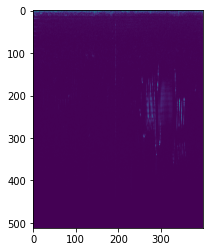

In [200]:
plt.imshow(spec)


In [114]:
xeno_df


,name,label
0,xenobirds\Blackbird\xc120750.wav,Blackbird
1,xenobirds\Blackbird\xc142612.wav,Blackbird
2,xenobirds\Blackbird\xc177025.wav,Blackbird
3,xenobirds\Blackbird\xc177026.wav,Blackbird
4,xenobirds\Blackbird\xc177027.wav,Blackbird
...,...,...
1787,xenobirds\Yellowhammer\xc759870.wav,Yellowhammer
1788,xenobirds\Yellowhammer\xc759872.wav,Yellowhammer
1789,xenobirds\Yellowhammer\xc759876.wav,Yellowhammer
1790,xenobirds\Yellowhammer\xc762387.wav,Yellowhammer


In [115]:
t_ds = tf.data.Dataset.from_tensor_slices(xeno_df)
wave_ds = t_ds.map(get_waveform_and_label, num_parallel_calls=AUTOTUNE)


In [117]:
for x, y in wave_ds.take(10):
    print(x.shape)
    print(y)


(661500,)
tf.Tensor(b'Blackbird', shape=(), dtype=string)
(124116,)
tf.Tensor(b'Blackbird', shape=(), dtype=string)
(661500,)
tf.Tensor(b'Blackbird', shape=(), dtype=string)
(661500,)
tf.Tensor(b'Blackbird', shape=(), dtype=string)
(661500,)
tf.Tensor(b'Blackbird', shape=(), dtype=string)
(654317,)
tf.Tensor(b'Blackbird', shape=(), dtype=string)
(661500,)
tf.Tensor(b'Blackbird', shape=(), dtype=string)
(653184,)
tf.Tensor(b'Blackbird', shape=(), dtype=string)
(720000,)
tf.Tensor(b'Blackbird', shape=(), dtype=string)
(720000,)
tf.Tensor(b'Blackbird', shape=(), dtype=string)


In [199]:
for x, y in wave_ds.take(5):
    aud = x
    lab = y
    comp_spec = gen_complex_spec(x, 44100)
    spec, labid = get_spectrogram_and_label_id(
        (aud, lab), choices=['Mod'], categories=pop_classes, req_width=comp_spec.shape[0])


In [200]:
for x, y in wave_ds.take(50):
    aud = x
    lab = y
    comp_spec = gen_complex_spec(x, 44100)
    spec2, labid2 = get_spectrogram_and_label_id(
        (aud, lab), choices=['Mod'], categories=pop_classes, req_width=comp_spec.shape[0])


In [201]:
for x, y in wave_ds.take(100):
    aud = x
    lab = y
    comp_spec = gen_complex_spec(x, 44100)
    spec3, labid3 = get_spectrogram_and_label_id(
        (aud, lab), choices=['Mod'], categories=pop_classes, req_width=comp_spec.shape[0])
    # print(spec.shape)
    # print(x)
    # print(y)


In [203]:
print(spec.shape, labid)
print(spec2.shape, labid2)
print(spec3.shape, labid3)


(512, 765, 1) tf.Tensor(0, shape=(), dtype=int64)
(512, 765, 1) tf.Tensor(0, shape=(), dtype=int64)
(512, 765, 1) tf.Tensor(1, shape=(), dtype=int64)


In [174]:
req_width = 400


In [175]:
spec.shape


TensorShape([765, 513])

In [181]:
spec_shp = spec.shape
dataset = tf.data.Dataset.from_tensor_slices(
    np.arange(spec_shp[0]*spec_shp[1]).reshape(spec_shp[0], spec_shp[1]))
dataset = dataset.window(size=400, shift=100, drop_remainder=True)
dataset = dataset.flat_map(lambda x: x.batch(3))
for d in dataset:
    print(d)


tf.Tensor(
[[   0    1    2 ...  510  511  512]
 [ 513  514  515 ... 1023 1024 1025]
 [1026 1027 1028 ... 1536 1537 1538]], shape=(3, 513), dtype=int32)
tf.Tensor(
[[1539 1540 1541 ... 2049 2050 2051]
 [2052 2053 2054 ... 2562 2563 2564]
 [2565 2566 2567 ... 3075 3076 3077]], shape=(3, 513), dtype=int32)
tf.Tensor(
[[3078 3079 3080 ... 3588 3589 3590]
 [3591 3592 3593 ... 4101 4102 4103]
 [4104 4105 4106 ... 4614 4615 4616]], shape=(3, 513), dtype=int32)
tf.Tensor(
[[4617 4618 4619 ... 5127 5128 5129]
 [5130 5131 5132 ... 5640 5641 5642]
 [5643 5644 5645 ... 6153 6154 6155]], shape=(3, 513), dtype=int32)
tf.Tensor(
[[6156 6157 6158 ... 6666 6667 6668]
 [6669 6670 6671 ... 7179 7180 7181]
 [7182 7183 7184 ... 7692 7693 7694]], shape=(3, 513), dtype=int32)
tf.Tensor(
[[7695 7696 7697 ... 8205 8206 8207]
 [8208 8209 8210 ... 8718 8719 8720]
 [8721 8722 8723 ... 9231 9232 9233]], shape=(3, 513), dtype=int32)
tf.Tensor(
[[ 9234  9235  9236 ...  9744  9745  9746]
 [ 9747  9748  9749 ... 1025

In [182]:
spec_c = spec
if spec_c.shape[0] <= req_width:
    if 2*spec_c.shape[0] <= req_width:
        spec_c = tf.concat([spec_c, spec_c], axis=0)
    zero_pad = tf.ones(
        (tf.constant(req_width) - spec_c.shape[0], spec_c.shape[1]))*1e-8
    spec_c = tf.concat([spec_c, zero_pad], axis=0)
else:
    spec_c = tf.slice(spec, [0, 0], [req_width, spec.shape[1]])
spec_c


<tf.Tensor: shape=(400, 513), dtype=complex64, numpy=
array([[ 1.1192086e-01+0.0000000e+00j,  4.5886916e-01-1.0949249e+00j,
        -7.4428529e-01+7.2420406e-01j, ...,
         4.6640635e-05-1.5315413e-04j, -1.2949109e-05+2.7537346e-05j,
        -1.1295080e-05+0.0000000e+00j],
       [-2.2803521e+00+0.0000000e+00j,  1.9422232e+00+7.5784326e-02j,
        -1.1314855e+00+2.9355678e-01j, ...,
         4.7504902e-05-1.2296438e-04j, -1.7362833e-04+9.3691051e-05j,
         2.0015240e-04+0.0000000e+00j],
       [-1.5694007e-02+0.0000000e+00j, -5.5013336e-02+5.1241148e-01j,
         7.0307866e-02-2.9091328e-01j, ...,
         1.4685094e-05+1.2904406e-04j,  1.2127683e-05-1.0883808e-04j,
        -7.9235062e-05+0.0000000e+00j],
       ...,
       [-8.4219933e+00+0.0000000e+00j,  5.4541683e+00+1.1571934e+00j,
        -1.3100286e+00-1.6322193e+00j, ...,
         1.8399954e-04+7.5757504e-05j, -1.5759468e-04-2.4855137e-05j,
         1.3160706e-04+0.0000000e+00j],
       [-8.7432709e+00+0.0000000e+00j,

In [183]:
spec.shape, aud, lab


(TensorShape([765, 513]),
 <tf.Tensor: shape=(661500,), dtype=float32, numpy=
 array([-4.9743652e-03, -3.8146973e-03, -3.2958984e-03, ...,
         2.7465820e-04,  6.1035156e-05, -8.5449219e-04], dtype=float32)>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'Chaffinch'>)

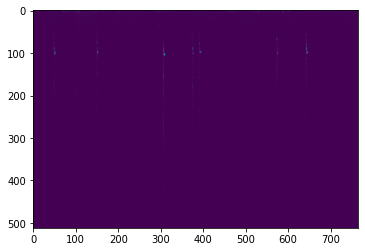

In [186]:
plt.imshow(spec)


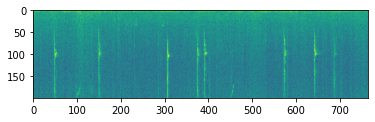

In [189]:
plt.imshow(np.log(spec[:200, :]))


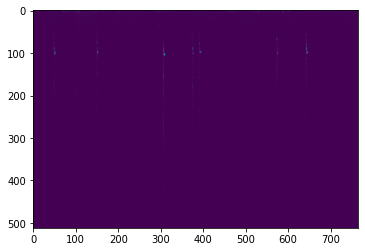

In [208]:
plt.imshow(spec3)


In [213]:
tf.reduce_sum(tf.stack([spec, spec2, spec3], axis=2))


<tf.Tensor: shape=(), dtype=float32, numpy=109614.375>

In [211]:
tf.reduce_all(tf.math.equal(spec2, tf.math.reduce_max(
    tf.stack((spec, spec2, spec3), axis=2), axis=2)))


<tf.Tensor: shape=(), dtype=bool, numpy=False>

In [327]:
spec


(<tf.Tensor: shape=(512, 400, 1), dtype=float32, numpy=
 array([[[1.75509063e-04],
         [9.83367790e-05],
         [2.16343527e-04],
         ...,
         [1.17367505e-04],
         [2.59139015e-05],
         [3.94168092e-05]],
 
        [[2.74703663e-04],
         [1.48126681e-04],
         [2.51427351e-04],
         ...,
         [1.93346656e-04],
         [1.74530287e-04],
         [1.26891624e-04]],
 
        [[4.74826375e-04],
         [1.29049047e-04],
         [4.30452230e-04],
         ...,
         [3.44464759e-04],
         [4.05845902e-04],
         [6.83886319e-05]],
 
        ...,
 
        [[1.04316357e-04],
         [1.49417465e-04],
         [2.10679937e-04],
         ...,
         [4.50283296e-05],
         [9.13941913e-05],
         [1.22065889e-04]],
 
        [[1.25450213e-04],
         [7.01972895e-05],
         [1.30798115e-04],
         ...,
         [1.25537317e-05],
         [7.40072574e-05],
         [2.60217959e-04]],
 
        [[1.28067331e-04],
       

In [219]:
tf.reduce_sum(tf.stack([spec, spec2, spec3], axis=2), axis=[0, 1, 3])


<tf.Tensor: shape=(3,), dtype=float32, numpy=array([59632.37 , 33322.75 , 16619.068], dtype=float32)>

In [225]:
# Create a dataset containing a 2D tensor
dataset = tf.data.Dataset.from_tensor_slices(spec)

# Define a function that splits the 2D tensor into multiple overlapping tensors


def split_tensor(tensor):
    # Split the tensor along the first axis
    tensors = tf.split(tensor, num_or_size_splits=3, axis=0)
    # Pad the smaller tensors to make them the same size as the largest tensor
    tensors = [tf.pad(t, [[0, 1], [0, 0]]) for t in tensors]
    return tensors


# Use the map method to apply the split_tensor function to each element in the dataset
dataset = dataset.map(split_tensor)

# Print the tensors in the dataset
for tensor in dataset.take(1):
    print(tensor[0].shape)


(256, 1)


In [299]:
#dataset = tf.data.Dataset.from_tensor_slices(spec)
def split_tensor(tensor, lab):
    # Split the tensor along the first axis
    #tensor = tensor[0]
    tensors = []
    for i in range(0, tf.shape(tensor)[0] - 400 + 1, 100):
        slice_start = i
        slice_end = i + 400
        # tensors.append(tensor)
        tensors.append(tf.slice(tensor, [i, 0, 0], [400, 400, 1]))
# )
        # tensors.append(5)#tensor[slice_start:slice_end,:])
    return tensors
#dataset = dataset.map(split_tensor)
# for tensor in dataset.take(1):
#  print(tensor)


In [300]:
for x, y in train_ds.unbatch().take(4):
    print(x.shape)


(512, 400, 1)
(512, 400, 1)
(512, 400, 1)
(512, 400, 1)


In [323]:
split_ds = train_ds.unbatch()  # .map(split_tensor)
for tensor, _ in split_ds:  # .take(1):
    print(tensor)  # [0].shape)


tf.Tensor(
[[[6.8261921e-01]
  [2.0913525e+00]
  [3.7125809e+00]
  ...
  [1.1426880e+00]
  [1.1753017e+00]
  [1.1696124e+00]]

 [[9.7157937e-01]
  [2.5859914e+00]
  [4.1970696e+00]
  ...
  [2.1503108e+00]
  [2.3674204e+00]
  [2.1959136e+00]]

 [[1.3390026e+00]
  [2.1899948e+00]
  [9.7331005e-01]
  ...
  [1.1125331e+00]
  [1.4906353e+00]
  [2.1069369e+00]]

 ...

 [[1.2499256e-04]
  [1.7882948e-04]
  [1.1039018e-04]
  ...
  [1.4447469e-04]
  [2.5094260e-04]
  [2.5648437e-04]]

 [[4.0458428e-05]
  [1.6706502e-04]
  [5.3261345e-05]
  ...
  [1.8153996e-04]
  [1.3156200e-04]
  [3.3420140e-05]]

 [[3.8146973e-05]
  [1.4066696e-04]
  [9.7036362e-05]
  ...
  [5.9336424e-05]
  [3.8964674e-05]
  [1.2481213e-04]]], shape=(512, 400, 1), dtype=float32)
tf.Tensor(
[[[0.0000000e+00]
  [1.9351933e-04]
  [1.2748608e-03]
  ...
  [1.8035997e-02]
  [1.1971041e-02]
  [1.0908360e-02]]

 [[0.0000000e+00]
  [9.0287061e-04]
  [2.8544343e-03]
  ...
  [5.1067408e-02]
  [3.1779010e-02]
  [2.6714269e-02]]

 [[0.00

In [444]:
tf.shape(tensor)
spec[0]


<tf.Tensor: shape=(512, 400, 1), dtype=float32, numpy=
array([[[1.75509063e-04],
        [9.83367790e-05],
        [2.16343527e-04],
        ...,
        [1.17367505e-04],
        [2.59139015e-05],
        [3.94168092e-05]],

       [[2.74703663e-04],
        [1.48126681e-04],
        [2.51427351e-04],
        ...,
        [1.93346656e-04],
        [1.74530287e-04],
        [1.26891624e-04]],

       [[4.74826375e-04],
        [1.29049047e-04],
        [4.30452230e-04],
        ...,
        [3.44464759e-04],
        [4.05845902e-04],
        [6.83886319e-05]],

       ...,

       [[1.04316357e-04],
        [1.49417465e-04],
        [2.10679937e-04],
        ...,
        [4.50283296e-05],
        [9.13941913e-05],
        [1.22065889e-04]],

       [[1.25450213e-04],
        [7.01972895e-05],
        [1.30798115e-04],
        ...,
        [1.25537317e-05],
        [7.40072574e-05],
        [2.60217959e-04]],

       [[1.28067331e-04],
        [5.31098340e-05],
        [6.88966829e-05],

In [441]:
def split_tensor(x_tuple):
    tensor, lab = x_tuple[0], x_tuple[1]
    # Split the tensor along the first axis
    tensors = []
    means   = []
    #tensor  = tf.squeeze(tensor)
    for i in range(0, tf.shape(tensor)[1] - 400 + 1, 100):
        #t_slice = 5
        #print(tensor.shape)
        t_slice = tf.slice(spec[0], [0, i, 0], [400, 400, 1])
        #print(t_slice.shape)
        #t_slice = tf.squeeze(t_slice)
        t_mean = tf.math.reduce_mean(t_slice)
        tensors.append(t_slice)
        means.append(t_mean)

    return tensors, means


In [474]:
def split_tensor(x_tuple):
    tensor, lab = x_tuple[0], x_tuple[1]
  # Split the tensor along the first axis
    tensors = []
    means = []
    for i in range(0, tf.shape(tensor)[0] - 400 + 1, 100):
      #print(i)
      tensor_slice = tf.slice(tensor, [0, 0, 0], [512, 100, 1])
      #tensors.append(tensor_slice)
      tensors = tf.concat([tensors, tensor_slice], axis=0)
      #means.append(tf.math.reduce_mean(tensor_slice))
    return tensors, means

In [475]:
#dataset = train_ds.map(split_tensor)
dataset = train_ds.unbatch().map(lambda x, y: split_tensor((x, y)),
                                 num_parallel_calls=AUTOTUNE)

# Iterate over the dataset and print the tensors
for tensor, means in dataset:
    print(tensor.shape)
    #if tf.argmax(means) is None:
    #    print(tf.argmax(means))
    #print(tf.argmax(means))

ValueError: in user code:

    <ipython-input-314-416889e5646b>:2 None  *
        lambda x, y: split_tensor((x, y))
    <ipython-input-474-d5ea2c57a108>:10 split_tensor  *
        tensors = tf.concat([tensors, tensor_slice], axis=0)
    c:\Users\Anthony\Anaconda3\lib\site-packages\tensorflow\python\util\dispatch.py:206 wrapper  **
        return target(*args, **kwargs)
    c:\Users\Anthony\Anaconda3\lib\site-packages\tensorflow\python\ops\array_ops.py:1769 concat
        return gen_array_ops.concat_v2(values=values, axis=axis, name=name)
    c:\Users\Anthony\Anaconda3\lib\site-packages\tensorflow\python\ops\gen_array_ops.py:1226 concat_v2
        _, _, _op, _outputs = _op_def_library._apply_op_helper(
    c:\Users\Anthony\Anaconda3\lib\site-packages\tensorflow\python\framework\op_def_library.py:748 _apply_op_helper
        op = g._create_op_internal(op_type_name, inputs, dtypes=None,
    c:\Users\Anthony\Anaconda3\lib\site-packages\tensorflow\python\framework\func_graph.py:599 _create_

In [363]:
def tensors_getmax(x_tuple):
    tensors, means = x_tuple[0], x_tuple[1]
    max_index = tf.argmax(means)
    max_tensor = tensors[max_index]
    return max_tensor

In [364]:
dataset_max = dataset.map(lambda x, y: tensors_getmax((x, y)), num_parallel_calls=AUTOTUNE)

In [365]:
for tensor in dataset_max.take(4):
    print(tensor)

tf.Tensor(
[[[6.8261921e-01]
  [2.0913525e+00]
  [3.7125809e+00]
  ...
  [4.3252869e+00]
  [4.6185408e+00]
  [5.9694991e+00]]

 [[9.7157937e-01]
  [2.5859914e+00]
  [4.1970696e+00]
  ...
  [3.1803288e+00]
  [3.8732409e+00]
  [4.8613024e+00]]

 [[1.3390026e+00]
  [2.1899948e+00]
  [9.7331005e-01]
  ...
  [2.6286423e-01]
  [1.6466686e+00]
  [1.0484965e+00]]

 ...

 [[1.2499256e-04]
  [1.7882948e-04]
  [1.1039018e-04]
  ...
  [1.3942627e-04]
  [2.0302631e-04]
  [5.3889060e-05]]

 [[4.0458428e-05]
  [1.6706502e-04]
  [5.3261345e-05]
  ...
  [2.8172077e-04]
  [2.0422142e-04]
  [2.5093398e-04]]

 [[3.8146973e-05]
  [1.4066696e-04]
  [9.7036362e-05]
  ...
  [3.7896633e-04]
  [1.3554096e-04]
  [3.9231777e-04]]], shape=(512, 200, 1), dtype=float32)
tf.Tensor(
[[[0.0000000e+00]
  [1.9351933e-04]
  [1.2748608e-03]
  ...
  [5.2653616e-03]
  [1.3508060e-02]
  [7.4332668e-03]]

 [[0.0000000e+00]
  [9.0287061e-04]
  [2.8544343e-03]
  ...
  [3.6006279e-02]
  [8.2347952e-02]
  [6.1469004e-02]]

 [[0.00

In [359]:
# Flatten the dataset to get a list of tensors and means
tensors = []
means = []
for sublist in dataset:
    for tensor, mean in zip(sublist[0], sublist[1]):
        tensors.append(tensor)
        means.append(mean)

# Find the tensor with the maximum mean
max_index = tf.argmax(means)
max_tensor = tensors[max_index]

# Print the tensor with the maximum mean
print(max_tensor.shape)


(512, 200, 1)


In [340]:
max_tensor


<tf.Tensor: shape=(200, 400, 1), dtype=float32, numpy=
array([[[0.        ],
        [0.11001562],
        [1.3685166 ],
        ...,
        [0.43829823],
        [0.2695625 ],
        [0.6826482 ]],

       [[0.        ],
        [0.11321582],
        [0.30912626],
        ...,
        [1.4189922 ],
        [0.6415703 ],
        [1.1181515 ]],

       [[0.        ],
        [0.11532276],
        [1.3894026 ],
        ...,
        [2.328891  ],
        [0.54676235],
        [1.1259726 ]],

       ...,

       [[0.        ],
        [0.09209733],
        [0.14243837],
        ...,
        [0.46302912],
        [0.39913332],
        [0.06743874]],

       [[0.        ],
        [0.09341921],
        [1.4685664 ],
        ...,
        [0.3738688 ],
        [1.1978506 ],
        [0.14993235]],

       [[0.        ],
        [0.0932264 ],
        [1.8274757 ],
        ...,
        [0.4918052 ],
        [1.4378834 ],
        [0.17763677]]], dtype=float32)>